In [4]:
# Stream IMERG data from Kerchunk virtual data stores
#
# 8/27/2026 JRS
# Revised 9/30/2026 BOM
# Use nasa-gesdisc-kerchunk environment

import warnings
import earthaccess
import xarray as xr

auth = earthaccess.login(strategy="netrc")
bearer_token = auth.token["access_token"]

In [5]:
# Create virtual dataset loader function (from Chris B's How To)
def get_vds(parq: str, chunks: dict={}, **kwargs):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=xr.SerializationWarning)
        return xr.open_dataset(
            "reference://",
            engine="zarr",
            chunks=chunks,
            backend_kwargs={
                "storage_options": {
                    "fo": str(parq),
                    "remote_protocol": "https",
                    "asynchronous": True,
                    "remote_options": {
                        "headers": {"Authorization": f'Bearer {bearer_token}'},
                        "asynchronous": True,
                    }
                },
                "consolidated": True
            },
            **kwargs
        )

In [6]:
%%time
# Read in kerchunk files of IMERG data (one year each) and concatenate them
vds2010 = get_vds("https://data.gesdisc.earthdata.nasa.gov/browse/kerchunk/GPM_L3/GPM_3IMERGDF.07/2010.parq")
vds2011 = get_vds("https://data.gesdisc.earthdata.nasa.gov/browse/kerchunk/GPM_L3/GPM_3IMERGDF.07/2011.parq")

vds_concat = xr.concat([vds2010, vds2011], dim="time")
vds_concat.attrs["BeginDate"] = str(vds_concat.time.min().dt.date.values)
vds_concat.attrs["EndDate"] = str(vds_concat.time.max().dt.date.values)
print(vds_concat)


<xarray.Dataset> Size: 170GB
Dimensions:                         (time: 730, lon: 3600, lat: 1800, nv: 2)
Coordinates:
  * time                            (time) datetime64[ns] 6kB 2010-01-01 ... ...
  * lon                             (lon) float32 14kB -179.9 -179.9 ... 179.9
  * lat                             (lat) float64 14kB -89.95 -89.85 ... 89.95
Dimensions without coordinates: nv
Data variables:
    MWprecipitation                 (time, lon, lat) float32 19GB dask.array<chunksize=(1, 3600, 900), meta=np.ndarray>
    MWprecipitation_cnt             (time, lon, lat) float32 19GB dask.array<chunksize=(1, 3600, 900), meta=np.ndarray>
    MWprecipitation_cnt_cond        (time, lon, lat) float32 19GB dask.array<chunksize=(1, 3600, 900), meta=np.ndarray>
    precipitation                   (time, lon, lat) float32 19GB dask.array<chunksize=(1, 3600, 900), meta=np.ndarray>
    precipitation_cnt               (time, lon, lat) float32 19GB dask.array<chunksize=(1, 3600, 900), meta=np.

In [ ]:
vds_concat_sub = vds_concat['precipitation'].sel(
    lat=slice(24, 34),
    lon=slice(-103, -93)
)
print(vds_concat_sub)

In [7]:
%%time
# Here we use list comphrehension to make a list of the years "str_yrs" and insert into the corresponding urls to be opened with the get_vds function
# Then those virtual data store references (or Kerchunk files) for each year are stored in "vds_lst" to be concatentated in the next step
import numpy as np
str_yrs = [str(x) for x in np.arange(1998,2026,1)] 
vds_lst = [get_vds(f"https://data.gesdisc.earthdata.nasa.gov/browse/kerchunk/GPM_L3/GPM_3IMERGDF.07/{x}.parq") for x in str_yrs]
vds_lst

CPU times: total: 2.64 s
Wall time: 2min 47s


[<xarray.Dataset> Size: 85GB
 Dimensions:                         (time: 365, lon: 3600, lat: 1800, nv: 2)
 Coordinates:
   * time                            (time) datetime64[ns] 3kB 1998-01-01 ... ...
   * lon                             (lon) float32 14kB -179.9 -179.9 ... 179.9
   * lat                             (lat) float64 14kB -89.95 -89.85 ... 89.95
 Dimensions without coordinates: nv
 Data variables:
     MWprecipitation                 (time, lon, lat) float32 9GB dask.array<chunksize=(1, 3600, 900), meta=np.ndarray>
     MWprecipitation_cnt             (time, lon, lat) float32 9GB dask.array<chunksize=(1, 3600, 900), meta=np.ndarray>
     MWprecipitation_cnt_cond        (time, lon, lat) float32 9GB dask.array<chunksize=(1, 3600, 900), meta=np.ndarray>
     precipitation                   (time, lon, lat) float32 9GB dask.array<chunksize=(1, 3600, 900), meta=np.ndarray>
     precipitation_cnt               (time, lon, lat) float32 9GB dask.array<chunksize=(1, 3600, 900), m

In [9]:
%%time
# Xarray concatenate as shown above takes a list of Kerchunk files and concatenates them together along the time dimension
vds_concat = xr.concat(vds_lst, dim="time")
vds_concat.attrs["BeginDate"] = str(vds_concat.time.min().dt.date.values)
vds_concat.attrs["EndDate"] = str(vds_concat.time.max().dt.date.values)
print(vds_concat)

<xarray.Dataset> Size: 2TB
Dimensions:                         (time: 10135, lon: 3600, lat: 1800, nv: 2)
Coordinates:
  * time                            (time) datetime64[ns] 81kB 1998-01-01 ......
  * lon                             (lon) float32 14kB -179.9 -179.9 ... 179.9
  * lat                             (lat) float64 14kB -89.95 -89.85 ... 89.95
Dimensions without coordinates: nv
Data variables:
    MWprecipitation                 (time, lon, lat) float32 263GB dask.array<chunksize=(1, 3600, 900), meta=np.ndarray>
    MWprecipitation_cnt             (time, lon, lat) float32 263GB dask.array<chunksize=(1, 3600, 900), meta=np.ndarray>
    MWprecipitation_cnt_cond        (time, lon, lat) float32 263GB dask.array<chunksize=(1, 3600, 900), meta=np.ndarray>
    precipitation                   (time, lon, lat) float32 263GB dask.array<chunksize=(1, 3600, 900), meta=np.ndarray>
    precipitation_cnt               (time, lon, lat) float32 263GB dask.array<chunksize=(1, 3600, 900), met

In [29]:
#We can further subset by selecting just the precipitation variables and select a smaller domain to reduce size of the data.
vds_concat_sub = vds_concat['precipitation'].sel(
    lat=slice(24, 34),
    lon=slice(-103, -93)
)
#Unsure of if this step is needed, but at somepoint I got an error in the year 2011 (could've been random), since you are subsetting to a variable the
#metadata from the dataset is not completely preserved so those need to be added back in manually if you were to save the data (i.e., as an .nc). 
vds_concat_sub.attrs["BeginDate"] = str(vds_concat_sub.time.min().dt.date.values)
vds_concat_sub.attrs["EndDate"] = str(vds_concat_sub.time.max().dt.date.values)
print(vds_concat_sub)

<xarray.DataArray 'precipitation' (time: 10135, lon: 100, lat: 100)> Size: 405MB
dask.array<getitem, shape=(10135, 100, 100), dtype=float32, chunksize=(1, 100, 100), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 81kB 1998-01-01 1998-01-02 ... 2025-09-30
  * lon      (lon) float32 400B -102.9 -102.8 -102.8 ... -93.25 -93.15 -93.05
  * lat      (lat) float64 800B 24.05 24.15 24.25 24.35 ... 33.75 33.85 33.95
Attributes:
    units:      mm/day
    long_name:  Daily mean precipitation rate (combined microwave-IR) estimat...
    BeginDate:  1998-01-01
    EndDate:    2025-09-30


In [30]:
#Verifying the estimated size of the data before calling compute
vds_concat_sub.nbytes

405400000

In [31]:
#Trying to estimate the size of the just the references (accuracy can vary), the point is to show we don't have this in memory yet
#thus it is very easy to manipulate which parts of the data we want before calling it into memory
from dask.sizeof import sizeof
sizeof(vds_concat_sub)

192

In [32]:
%%time
#Calling the data cube into memory
ds = vds_concat_sub.compute()

CPU times: total: 16min 48s
Wall time: 18min 24s


In [33]:
#printing out the DataArray
ds

<xarray.DataArray 'precipitation' (time: 10135, lon: 100, lat: 100)> Size: 405MB
array([[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 3.99999991e-02, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 1.99999996e-02, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 2.99999975e-02, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 1.49999997e-02, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
...
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [3.18500018e+00, 4.04500008e+00, 4.17499971e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [3.34500027e+00, 4.77499962e+00, 4.50000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[2.45499992e+00, 6.15000010e-01, 4.04999971e-01, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [1.77499986e+00, 1.40500009e+00, 5.79999983e-01, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [1.00000009e-01, 2.05000013e-01, 7.79999971e-01, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [1.51100006e+01, 2.02199974e+01, 1.30449982e+01, ...,
         0.00000000e+00, 1.25000000e-01, 4.05000031e-01],
        [1.31349993e+01, 2.17200012e+01, 1.52850008e+01, ...,
         4.99999989e-03, 0.00000000e+00, 8.50000009e-02],
        [7.47999954e+00, 1.09049988e+01, 1.59250002e+01, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]]],
      shape=(10135, 100, 100), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 81kB 1998-01-01 1998-01-02 ... 2025-09-30
  * lon      (lon) float32 400B -102.9 -102.8 -102.8 ... -93.25 -93.15 -93.05
  * lat      (lat) float64 800B 24.05 24.15 24.25 24.35 ... 33.75 33.85 33.95
Attributes:
    units:      mm/day
    long_name:  Daily mean precipitation rate (combined microwave-IR) estimat...
    BeginDate:  1998-01-01
    EndDate:    2025-09-30

In [36]:
#Confirming the size of the dataset in memory
sizeof(ds)

405400104

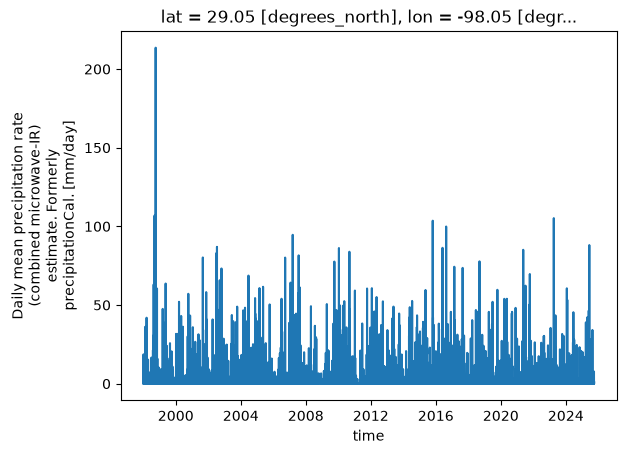

In [38]:
#Plotting a time series of GPM_IMERG_day at one location
import matplotlib.pyplot as plt
ds.sel(lat=29.01,lon=-98.01,method='nearest').plot()